## Observation physique de la ressource solaire locale

### Objectif de l’analyse exploratoire

Ce notebook vise à réaliser une observation physique et descriptive de la ressource solaire à l’échelle de plusieurs communes représentatives de la région Provence-Alpes-Côte d’Azur. L’objectif n’est pas d’optimiser directement un modèle de prédiction, mais de comprendre les déterminants physiques et météorologiques qui influencent la production photovoltaïque et sa variabilité au sein d’un même territoire.

À travers l’analyse comparative de l’irradiance solaire, de la nébulosité, de la température, du vent et de caractéristiques géographiques telles que l’altitude, ce travail met en évidence l’hétérogénéité des conditions locales, malgré une appartenance régionale commune. Cette approche permet de distinguer les facteurs statiques des facteurs dynamiques et de vérifier dans quelle mesure des variables simples peuvent expliquer les différences observées de ressource solaire.

Cette observation physique constitue une étape préalable essentielle à la construction des indicateurs de variabilité et au choix des variables explicatives utilisées par la suite dans les modèles de prévision.

In [1]:
import pandas as pd
import numpy as np

In [3]:
# à utiliser uniquement si en mode colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [17]:
# Chargement en mode colab
df = pd.read_csv(     "/content/drive/MyDrive/Jupyter Notebooks/analyse_variabilite_solaire_paca_feature_engineering/raw_2020_2024.csv" )

/tmp/ipython-input-211378783.py:2: DtypeWarning: Columns (6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(     "/content/drive/MyDrive/Jupyter Notebooks/analyse_variabilite_solaire_paca_feature_engineering/raw_2020_2024.csv" )


In [ ]:
# Chargement en mode colab
df = pd.read_csv(     "raw_2020_2024.csv" )

In [18]:
# Mise en index temporel
df = df.rename(columns={"datetime_utc": "Date"})
df["Date"] = pd.to_datetime(df["Date"], utc=True)
df = df.set_index("Date").sort_index()

# =========================================================
# 2. Liste des communes représentatives
# =========================================================

communes = ["CRU", "SEL", "SVT", "BRA", "EYG"]

# =========================================================
# 3. Construction du tableau comparatif
# =========================================================

rows = []

for c in communes:
    row = {
        "commune": c,

        # --- Géographie / site ---
        "altitude_moy_m": df[f"{c}_altitude"].mean(),

        # --- Ressource solaire ---
        "ghi_moy": df[f"{c}_GHI"].mean(),
        "ghi_std": df[f"{c}_GHI"].std(),

        "clear_sky_ratio_moy": (
            df[f"{c}_GHI"] / df[f"{c}_Clear sky GHI"]
        ).mean(),

        # --- Vent ---
        "vent_moy": df[f"{c}_Vitesse_Vent"].mean(),
        "vent_std": df[f"{c}_Vitesse_Vent"].std(),

        # --- Nébulosité ---
        "nebulosite_moy": df[f"{c}_Nebulosite"].mean(),
        "nebulosite_std": df[f"{c}_Nebulosite"].std(),
    }

    rows.append(row)

df_communes_compare = pd.DataFrame(rows)

# =========================================================
# 4. Affichage et export
# =========================================================

display(df_communes_compare)

# Export
df_communes_compare.to_csv(
    "analyse_comparee_communes_paca.csv",
    index=False,
    encoding="utf-8"
)

,commune,altitude_moy_m,ghi_moy,ghi_std,clear_sky_ratio_moy,vent_moy,vent_std,nebulosite_moy,nebulosite_std
0,CRU,0.332711,92.013446,133.891300,0.809827,2.406551,1.700155,53.615880,36.870783
1,SEL,0.334114,93.558402,135.743489,0.818195,1.705995,1.205290,56.536325,34.217805
2,SVT,0.331374,91.639114,132.732361,0.815199,2.812578,1.806434,52.330814,35.749373
3,BRA,0.330811,94.640089,136.732208,0.834667,2.713704,1.804534,46.548744,38.648557
4,EYG,0.331568,94.972173,137.318050,0.837184,2.941427,1.993310,51.525113,37.500944


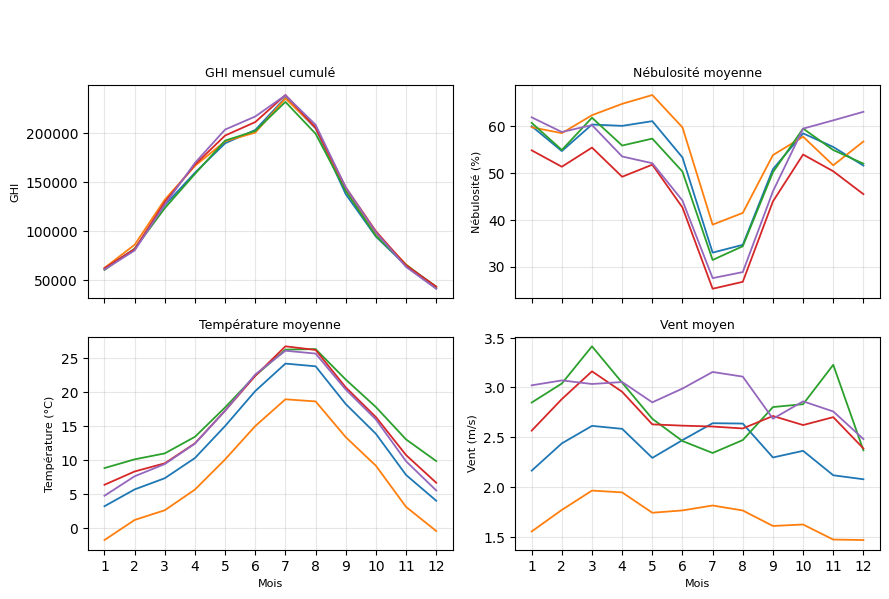

In [56]:
import matplotlib.pyplot as plt

communes = ["CRU", "SEL", "SVT", "BRA", "EYG"]

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(9, 6),   # très compact
    sharex=True
)

# =========================================================
# 1️⃣ GHI mensuel cumulé
# =========================================================
ax = axes[0, 0]

for c in communes:
    ghi_monthly = (
        df[f"{c}_GHI"]
        .resample("ME")
        .sum()
        .groupby(lambda x: x.month)
        .mean()
    )
    ax.plot(ghi_monthly.index, ghi_monthly.values, linewidth=1.3)

ax.set_title("GHI mensuel cumulé", fontsize=9)
ax.set_ylabel("GHI", fontsize=8)
ax.grid(True, alpha=0.3)

# =========================================================
# 2️⃣ Nébulosité moyenne mensuelle
# =========================================================
ax = axes[0, 1]

for c in communes:
    cloud_monthly = (
        df[f"{c}_Nebulosite"]
        .resample("ME")
        .mean()
        .groupby(lambda x: x.month)
        .mean()
    )
    ax.plot(cloud_monthly.index, cloud_monthly.values, linewidth=1.3)

ax.set_title("Nébulosité moyenne", fontsize=9)
ax.set_ylabel("Nébulosité (%)", fontsize=8)
ax.grid(True, alpha=0.3)

# =========================================================
# 3️⃣ Température moyenne mensuelle
# =========================================================
ax = axes[1, 0]

for c in communes:
    temp_monthly = (
        df[f"{c}_Temperature"]
        .resample("ME")
        .mean()
        .groupby(lambda x: x.month)
        .mean()
    )
    ax.plot(temp_monthly.index, temp_monthly.values, linewidth=1.3)

ax.set_title("Température moyenne", fontsize=9)
ax.set_ylabel("Température (°C)", fontsize=8)
ax.set_xlabel("Mois", fontsize=8)
ax.grid(True, alpha=0.3)

# =========================================================
# 4️⃣ Vent moyen mensuel
# =========================================================
ax = axes[1, 1]

for c in communes:
    wind_monthly = (
        df[f"{c}_Vitesse_Vent"]
        .resample("ME")
        .mean()
        .groupby(lambda x: x.month)
        .mean()
    )
    ax.plot(wind_monthly.index, wind_monthly.values, linewidth=1.3)

ax.set_title("Vent moyen", fontsize=9)
ax.set_ylabel("Vent (m/s)", fontsize=8)
ax.set_xlabel("Mois", fontsize=8)
ax.grid(True, alpha=0.3)

# =========================================================
# Légende unique
# =========================================================
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles,
    communes,
    loc="upper center",
    ncol=5,
    frameon=False,
    fontsize=8
)

plt.xticks(range(1, 13))
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

# Comparaison des ressources solaires locales

Bien que les communes sélectionnées appartiennent toutes à la même région administrative, l’analyse des cumuls mensuels de GHI met en évidence des différences persistantes de ressource solaire entre les sites. Ces écarts se maintiennent sur l’ensemble du cycle annuel, suggérant l’existence de régimes météorologiques locaux distincts. Cette hétérogénéité intra-régionale souligne l’intérêt de ne pas considérer la région comme un ensemble homogène du point de vue de la production photovoltaïque, et justifie l’utilisation de données météorologiques localisées dans l’analyse de la variabilité.

Altitude et ressource solaire

Afin d’évaluer l’influence potentielle de facteurs géographiques statiques sur la ressource solaire, une comparaison a été réalisée entre l’altitude moyenne des communes et leur GHI mensuel cumulé moyen. La représentation des deux variables sous forme normalisée met en évidence une absence de correspondance entre leurs profils respectifs. Les communes présentant les altitudes les plus élevées ne sont pas systématiquement associées aux niveaux de GHI les plus importants, et inversement. Cette observation indique que, à l’échelle régionale considérée, l’altitude seule ne constitue pas un facteur explicatif dominant de la ressource solaire. Les différences observées sont principalement imputables à des conditions météorologiques locales, notamment la nébulosité et les régimes atmosphériques.

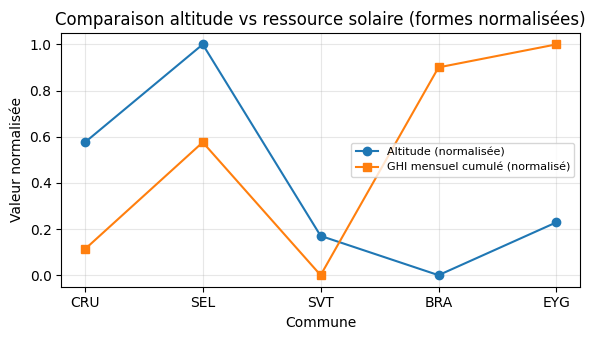

In [57]:


import numpy as np
import matplotlib.pyplot as plt

# Ordre des communes (identique sur les deux courbes)
communes = df_communes_compare["commune"]

# Altitude normalisée
altitude = df_communes_compare.set_index("commune")["altitude_moy_m"]
altitude_norm = (altitude - altitude.min()) / (altitude.max() - altitude.min())

# GHI mensuel cumulé moyen (depuis df_alt_ghi)
ghi = df_alt_ghi.set_index("commune")["ghi_mensuel_cumule_moyen"]
ghi_norm = (ghi - ghi.min()) / (ghi.max() - ghi.min())

# --- Plot ---
plt.figure(figsize=(6, 3.5))

plt.plot(communes, altitude_norm.loc[communes], marker="o", label="Altitude (normalisée)")
plt.plot(communes, ghi_norm.loc[communes], marker="s", label="GHI mensuel cumulé (normalisé)")

plt.xlabel("Commune")
plt.ylabel("Valeur normalisée")
plt.title("Comparaison altitude vs ressource solaire (formes normalisées)")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()